In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r'D:\Projects\smart-crop-assistant\smart-crop-ai\Crop_recommendation.csv')

# Basic info
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 5 rows:\n", df.head())


Shape: (2200, 8)

Data Types:
 N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

First 5 rows:
     N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


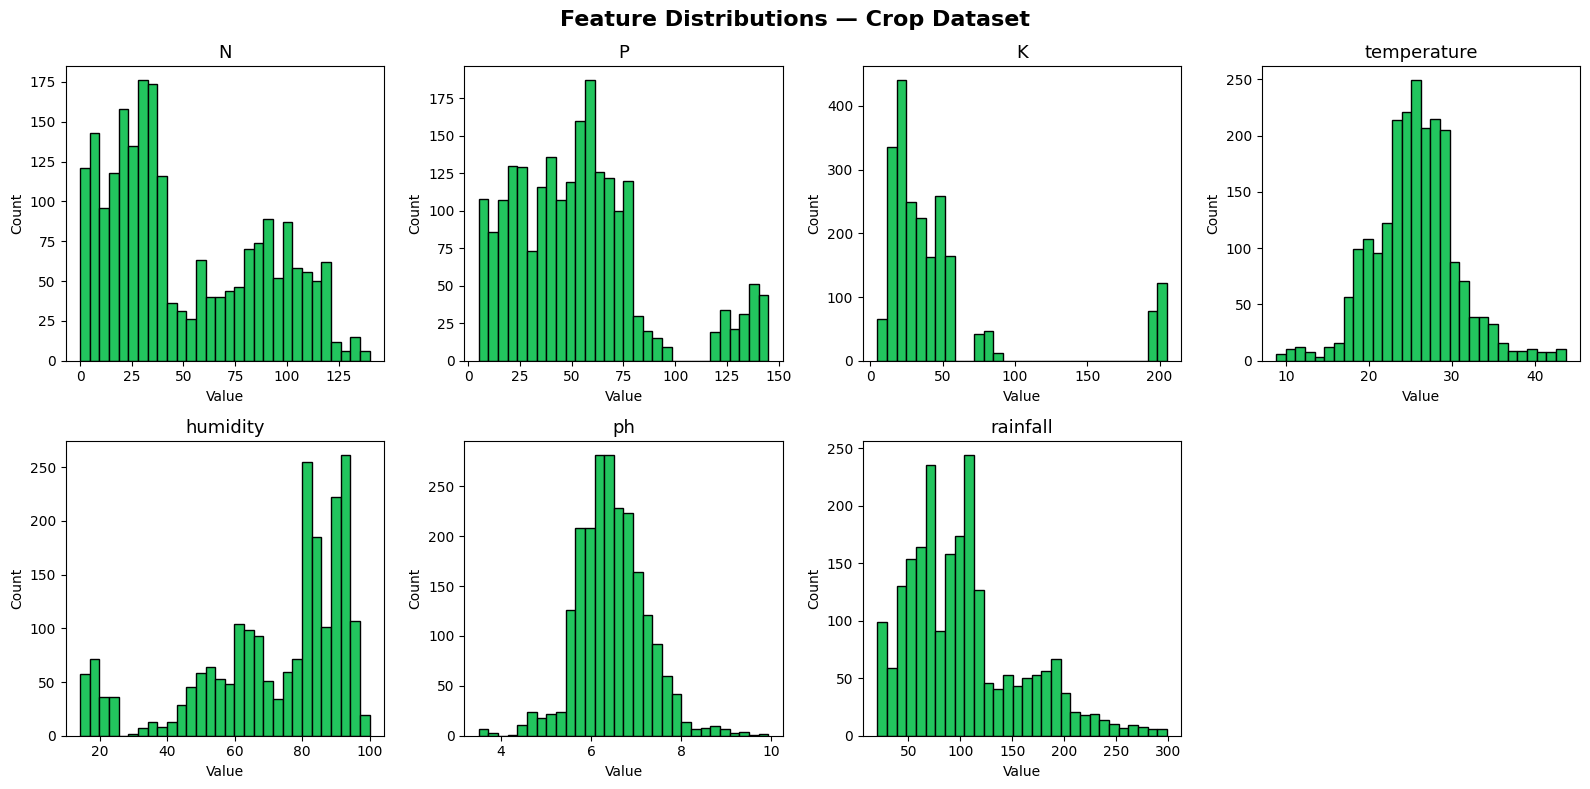

✅ Saved!


In [2]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=30, color='#22c55e', edgecolor='black')
    axes[i].set_title(feature, fontsize=13)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions — Crop Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\Projects\smart-crop-assistant\smart-crop-ai\feature_distributions.png', dpi=150)
plt.show()
print("✅ Saved!")

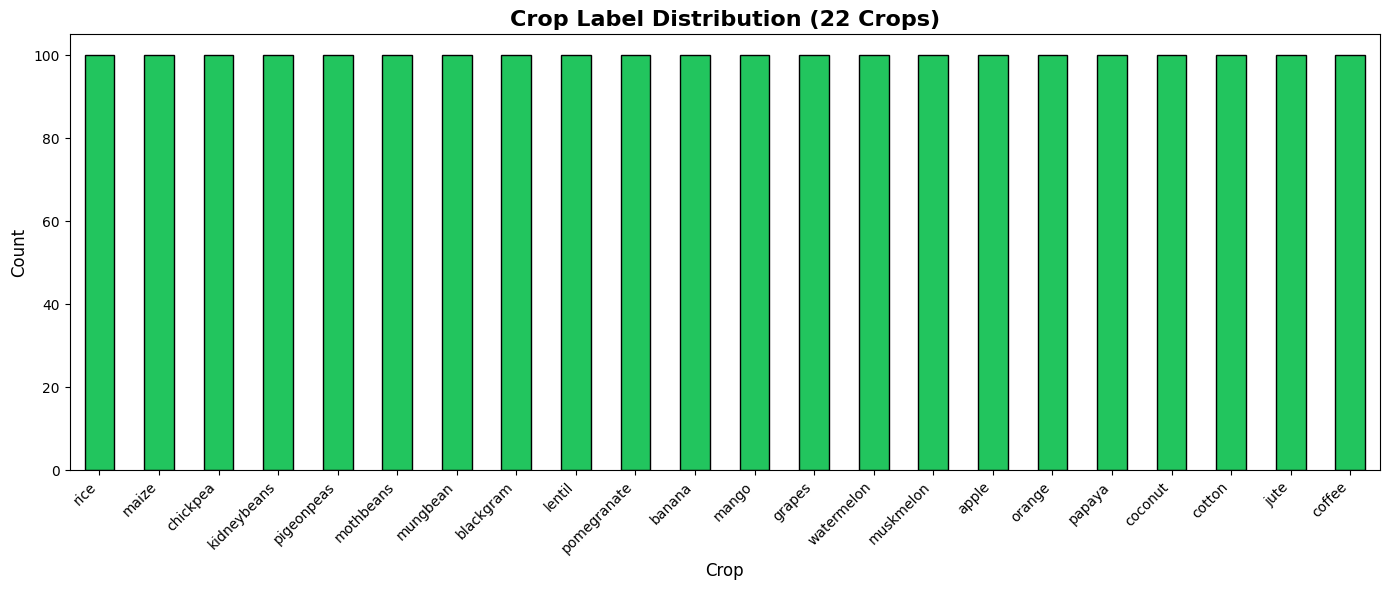

✅ Saved!


In [3]:
crop_counts = df['label'].value_counts()

plt.figure(figsize=(14, 6))
crop_counts.plot(kind='bar', color='#22c55e', edgecolor='black')
plt.title('Crop Label Distribution (22 Crops)', fontsize=16, fontweight='bold')
plt.xlabel('Crop', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r'D:\Projects\smart-crop-assistant\smart-crop-ai\crop_distribution.png', dpi=150)
plt.show()
print("✅ Saved!")

In [4]:
summary = f"""
=== Crop Dataset — EDA Findings Summary ===

1. DATASET SHAPE:
   - Rows: {df.shape[0]}
   - Columns: {df.shape[1]}

2. FEATURES:
   - N (Nitrogen):       min={df['N'].min()}, max={df['N'].max()}, mean={df['N'].mean():.1f}
   - P (Phosphorus):     min={df['P'].min()}, max={df['P'].max()}, mean={df['P'].mean():.1f}
   - K (Potassium):      min={df['K'].min()}, max={df['K'].max()}, mean={df['K'].mean():.1f}
   - Temperature:        min={df['temperature'].min():.1f}, max={df['temperature'].max():.1f}, mean={df['temperature'].mean():.1f}
   - Humidity:           min={df['humidity'].min():.1f}, max={df['humidity'].max():.1f}, mean={df['humidity'].mean():.1f}
   - pH:                 min={df['ph'].min():.1f}, max={df['ph'].max():.1f}, mean={df['ph'].mean():.1f}
   - Rainfall:           min={df['rainfall'].min():.1f}, max={df['rainfall'].max():.1f}, mean={df['rainfall'].mean():.1f}

3. MISSING VALUES: None ✅

4. CLASS DISTRIBUTION:
   - Total crops: {df['label'].nunique()}
   - Samples per crop: 100 (perfectly balanced) ✅

5. KEY OBSERVATIONS:
   - Dataset is clean with no nulls or duplicates
   - All 22 crops have equal representation
   - K (Potassium) has the widest range (0-205)
   - Temperature ranges from 8 to 44 degrees
"""

print(summary)

# Save to file
with open(r'D:\Projects\smart-crop-assistant\smart-crop-ai\eda_findings.txt', 'w') as f:
    f.write(summary)
print("✅ Saved!")


=== Crop Dataset — EDA Findings Summary ===

1. DATASET SHAPE:
   - Rows: 2200
   - Columns: 8

2. FEATURES:
   - N (Nitrogen):       min=0, max=140, mean=50.6
   - P (Phosphorus):     min=5, max=145, mean=53.4
   - K (Potassium):      min=5, max=205, mean=48.1
   - Temperature:        min=8.8, max=43.7, mean=25.6
   - Humidity:           min=14.3, max=100.0, mean=71.5
   - pH:                 min=3.5, max=9.9, mean=6.5
   - Rainfall:           min=20.2, max=298.6, mean=103.5

3. MISSING VALUES: None ✅

4. CLASS DISTRIBUTION:
   - Total crops: 22
   - Samples per crop: 100 (perfectly balanced) ✅

5. KEY OBSERVATIONS:
   - Dataset is clean with no nulls or duplicates
   - All 22 crops have equal representation
   - K (Potassium) has the widest range (0-205)
   - Temperature ranges from 8 to 44 degrees

✅ Saved!


In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pickle

# 1. Label Encoding
le = LabelEncoder()
df['crop_encoded'] = le.fit_transform(df['label'])
print("✅ Label Encoding done")
print("Classes:", list(le.classes_))

# 2. Features & Target
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['crop_encoded']

# 3. Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\n✅ Scaling done")
print("Mean:", X_scaled.mean().round(4))

# 4. Train/Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n✅ Split done")
print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

# 5. Save scaler
with open(r'D:\Projects\smart-crop-assistant\smart-crop-ai\scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\n✅ scaler.pkl saved!")

# Save label encoder
with open(r'D:\Projects\smart-crop-assistant\smart-crop-ai\label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("✅ label_encoder.pkl saved!")

✅ Label Encoding done
Classes: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']

✅ Scaling done
Mean: 0.0

✅ Split done
Train: 1760 samples
Test:  440 samples

✅ scaler.pkl saved!
✅ label_encoder.pkl saved!


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

# 1. Train with different n_estimators
for n in [50, 100, 200]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"n_estimators={n} → Accuracy: {acc*100:.2f}%")

n_estimators=50 → Accuracy: 99.55%
n_estimators=100 → Accuracy: 99.55%
n_estimators=200 → Accuracy: 99.55%


✅ Accuracy: 99.55%
✅ F1 Score: 99.55%


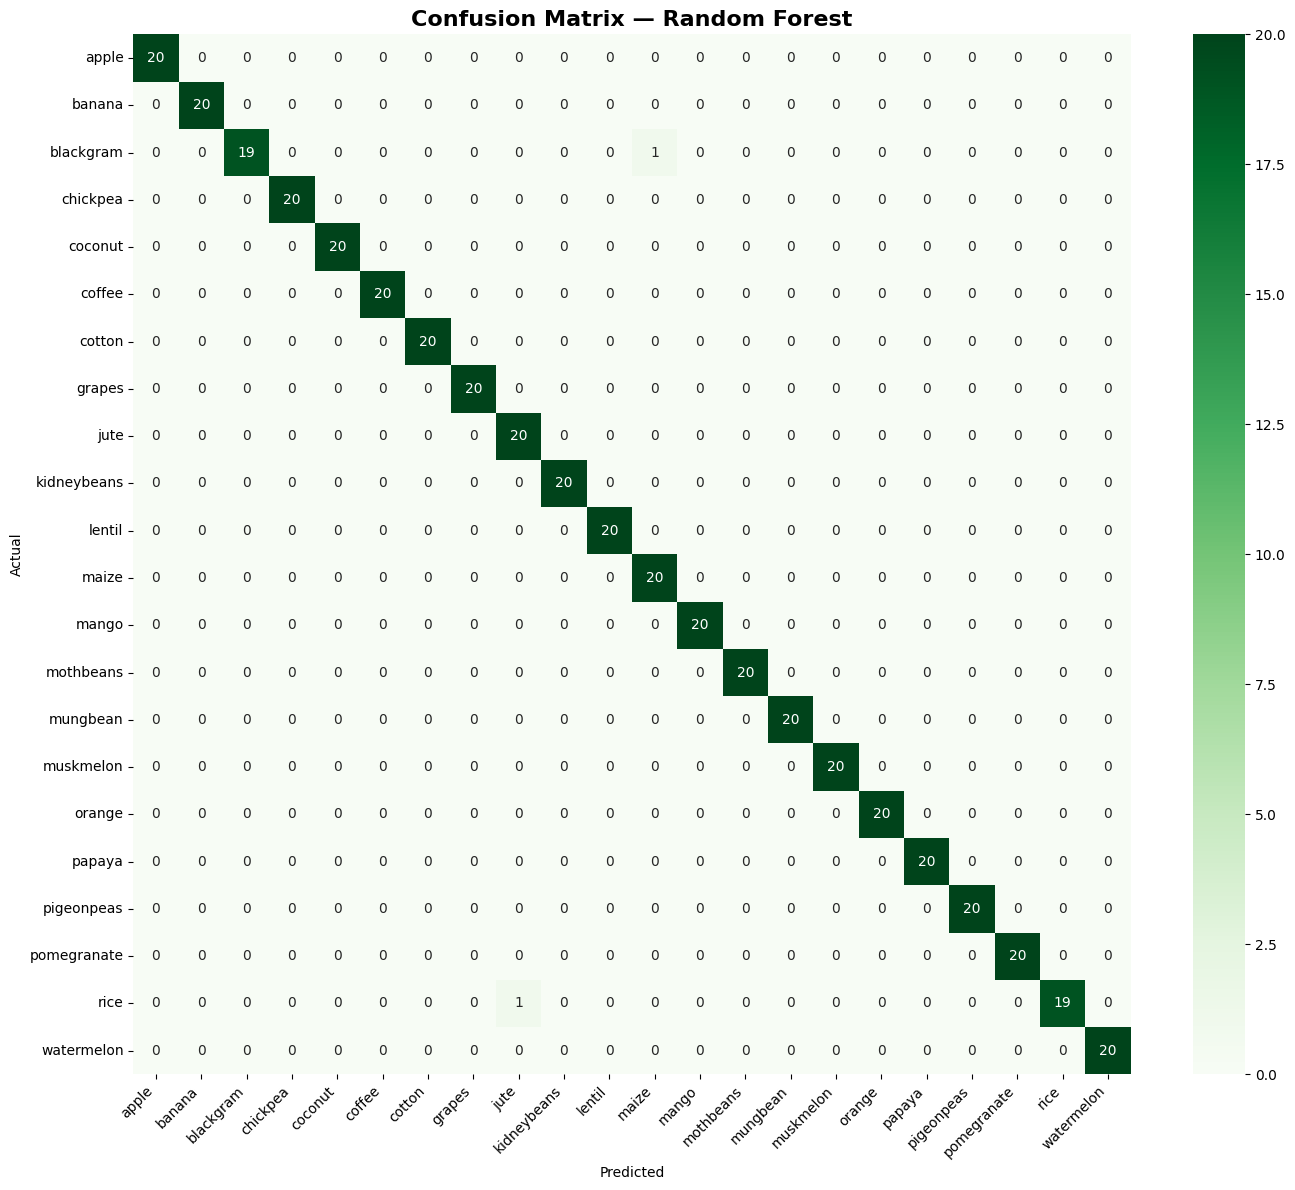

✅ crop_model.pkl saved!


In [8]:
# Train final model with n_estimators=100
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"✅ Accuracy: {acc*100:.2f}%")
print(f"✅ F1 Score: {f1*100:.2f}%")

# Confusion Matrix
plt.figure(figsize=(14, 12))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Random Forest', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r'D:\Projects\smart-crop-assistant\smart-crop-ai\confusion_matrix.png', dpi=150)
plt.show()

# Save model
with open(r'D:\Projects\smart-crop-assistant\smart-crop-ai\crop_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("✅ crop_model.pkl saved!")

In [ ]:
ك